In [18]:
import os
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

import time

In [4]:
from dotenv import load_dotenv
load_dotenv()

llm = ChatOpenAI(model ='gpt-4o-mini')

In [9]:
embedding_model = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [11]:
test_emb = embedding_model.embed_query('Hello')
# test_emb

In [12]:
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_core.stores import InMemoryByteStore

In [13]:
store = InMemoryByteStore()
cached_embeddings = CacheBackedEmbeddings.from_bytes_store(
                        embedding_model, store, namespace="embedding-cache")

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


In [14]:
texts = ["인공지능이 계속 발전하고 있습니다", "Langchain으로 RAG를 구현합시다"]
vecs1 = cached_embeddings.embed_documents(texts)

In [16]:
len(vecs1)

2

In [17]:
len(vecs1[0]), len(vecs1[1])

(1536, 1536)

In [19]:
start = time.time()
texts = ["오늘 점심에는 라면을 먹었습니다", "내일 저녁에는 햄버거를 먹을겁니다"]
vecs1 = cached_embeddings.embed_documents(texts)
t1 = time.time() - start
print(f"1차 call, {t1}초")

start = time.time()
vecs2 = cached_embeddings.embed_documents(texts)
t2 = time.time() - start
print(f"2차 call, {t2}초")


1차 call, 0.42476630210876465초
1차 call, 0.0014560222625732422초


In [20]:
start = time.time()
texts = ["오늘 점심에는 라면을 먹었습니다", "내일 저녁에는 햄버거를 먹을겁니다"]
vecs1 = cached_embeddings.embed_documents(texts)
t1 = time.time() - start
print(f"1차 call, {t1}초")

start = time.time()
vecs2 = cached_embeddings.embed_documents(texts)
t2 = time.time() - start
print(f"2차 call, {t2}초")


1차 call, 0.0015988349914550781초
2차 call, 0.001444101333618164초


In [21]:
import tiktoken

def count_tokens(text, model = 'gpt-4o-mini'):
    enc = tiktoken.encoding_for_model(model)
    return len(enc.encode(text))


In [27]:
def process_documents(docs, embedding_model, batch_size = 5):
    
    all_vectors = []
    total_tokens = 0
    
    start = time.time()
    
    for i in range(0, len(docs), batch_size):
        batch = docs[i:i+batch_size]
        batch_tokens = sum(count_tokens(d) for d in batch)
        total_tokens += batch_tokens
        
        vectors = embedding_model.embed_documents(batch)
        all_vectors.extend(vectors)
        
        progress = min(i+batch_size , len(docs))
        print(f" [{progress} / {len(docs)}] batch {i//batch_size + 1} process ({batch_tokens} tokens)")
        
    elapsed = time.time() - start
    
    print(f"completed, {len(docs)} documents, {total_tokens} tokens completed")
    print(f" {elapsed} seconds ")

In [28]:
docs = [f"doc {i} : 이것은 테스트 문서입니다. 인공지능에 관련한 문서입니다" for i in range(20)]
vectors = process_documents(docs, cached_embeddings, batch_size=5)

 [5 / 20] batch 1 process (100 tokens)
 [10 / 20] batch 2 process (100 tokens)
 [15 / 20] batch 3 process (100 tokens)
 [20 / 20] batch 4 process (100 tokens)
completed, 20 documents, 400 tokens completed
 3.5773513317108154 seconds 


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

In [40]:
pairs = [
    ("오늘 날씨가 좋다", "오늘은 화창한 날이다"),
    ("오늘 날씨가 좋다", "오늘 날씨가 나쁘고 미세먼지가 많다"),
    ("파이썬 프로그래밍", "python programming"),
    ("인공지능 기술", "맛있는 김치찌개"),
    ("서울은 한국의 수도입니다", "seoul is the capital of korea")
]

pairs = [
    ("나는 축구를 많이 좋아한다", "나는 축구를 싫어한다"),
    ("나는 축구를 많이 좋아한다", "나는 축구를 좋아한다"),
    ("나는 축구를 많이 싫어한다", "나는 축구를 싫어한다")
]

In [41]:
for text_a, text_b in pairs:
    embs = embedding_model.embed_documents([text_a, text_b])
    sim = cosine_similarity([embs[0]], [embs[1]])[0][0]
    
    print(f"similarity : {sim}, {text_a}, {text_b}")

similarity : 0.8318192024289336, 나는 축구를 많이 좋아한다, 나는 축구를 싫어한다
similarity : 0.9600213135445052, 나는 축구를 많이 좋아한다, 나는 축구를 좋아한다
similarity : 0.9490441953145348, 나는 축구를 많이 싫어한다, 나는 축구를 싫어한다


In [42]:
corpus = [
    "LangChain은 LLM 앱 개발 프레임워크입니다",
    "RAG는 검색 증강 생성 기술입니다",
    "벡터 데이터베이스는 임베딩을 저장합니다",
    "파인튜닝은 모델을 특정 데이터에 맞게 조정합니다",
    "프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다",
    "LangChain으로 챗봇 만들기",
    "React vs Vue 성능 비교",
    "GPT API 활용 가이드",
]

In [ ]:
query = 'AI 챗봇 개발하고 싶어요'

In [47]:
def find_most_similar(query, corpus, top_k = 3):
    
    all_texts = [query] + corpus
    all_embs = embedding_model.embed_documents(all_texts)
    query_emb = all_embs[0]
    corpus_emb = all_embs[1:]
    
    sims = cosine_similarity([query_emb], corpus_emb)[0]
    ranked = sorted(enumerate(sims), key=lambda x:x[1], reverse=True)
    
    for rank, (idx, sim) in enumerate(ranked):
        print(f"{rank} sim : {sim}, {corpus[idx]}")

    return ranked[:top_k]

In [48]:
find_most_similar('AI 챗봇 개발하고 싶어요', corpus)

0 sim : 0.5933640247466845, LangChain으로 챗봇 만들기
1 sim : 0.31324533537883414, LangChain은 LLM 앱 개발 프레임워크입니다
2 sim : 0.26393517531223126, 프롬프트 엔지니어링은 AI에게 좋은 지시를 작성하는 기술입니다
3 sim : 0.2396643800171736, RAG는 검색 증강 생성 기술입니다
4 sim : 0.21315640017919046, GPT API 활용 가이드
5 sim : 0.20571809126157856, 파인튜닝은 모델을 특정 데이터에 맞게 조정합니다
6 sim : 0.1854452745895149, 벡터 데이터베이스는 임베딩을 저장합니다
7 sim : 0.149594338287324, React vs Vue 성능 비교


[(5, np.float64(0.5933640247466845)),
 (0, np.float64(0.31324533537883414)),
 (4, np.float64(0.26393517531223126))]

In [50]:
from sklearn.decomposition import PCA
from sklearn.manifold  import TSNE

In [51]:
topic_sentences = {
    "tech": [
        "인공지능이 산업을 혁신하고 있다",
        "클라우드 컴퓨팅이 IT를 변화시킨다",
        "블록체인이 금융을 바꾸고 있다",
        "5G가 통신을 혁신한다",
    ],
    "sports": [
        "축구 경기에서 역전골이 터졌다",
        "올림픽에서 금메달을 획득했다",
        "야구 시즌이 개막했다",
        "마라톤 대회에서 신기록을 세웠다",
    ],
    "food": [
        "이 레스토랑의 파스타가 맛있었다",
        "한국 김치는 발효 식품이다",
        "새로운 카페에서 커피를 마셨다",
        "맛집 탐방이 요즘 인기다",
    ],
    "finance": [
        "주식 시장이 크게 하락했다",
        "비트코인 가격이 급등했다",
        "금리 인상이 예상된다",
        "환율이 급변하고 있다",
    ],
}

In [52]:
all_texts = []
all_labels = []
for topic, sents in topic_sentences.items():
    all_texts.extend(sents)
    all_labels.extend([topic] * len(sents))

In [55]:
all_embs = embedding_model.embed_documents(all_texts)


In [59]:
len(all_embs), len(all_embs[0])

(16, 1536)

In [61]:
# all_embs

In [57]:
import numpy as np
emb_matrix = np.array(all_embs)

In [62]:
emb_matrix

array([[ 5.53131104e-03,  8.70513916e-03,  2.40173340e-02, ...,
        -1.49459839e-02, -1.50394440e-03,  1.42974854e-02],
       [-1.26266479e-02,  8.85772705e-03,  3.22265625e-02, ...,
        -5.47180176e-02,  7.98797607e-03, -2.30865479e-02],
       [-1.30462646e-02,  4.10766602e-02, -1.60369873e-02, ...,
        -1.86614990e-02,  1.55868530e-02,  3.84521484e-03],
       ...,
       [-2.75268555e-02, -3.58581543e-02, -2.79998779e-02, ...,
         8.47625732e-03, -3.39150429e-05,  2.29949951e-02],
       [ 3.85742188e-02,  2.89611816e-02, -2.80303955e-02, ...,
        -9.64355469e-03,  1.01318359e-02,  8.15391541e-04],
       [-1.81732178e-02,  4.37545776e-03,  6.41632080e-03, ...,
        -1.42745972e-02, -2.41699219e-02, -1.98669434e-02]],
      shape=(16, 1536))

In [64]:
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(emb_matrix)

In [66]:
coords_2d

array([[ 0.3617807 ,  0.17708041],
       [ 0.40130031,  0.26978393],
       [-0.08063629,  0.2632866 ],
       [ 0.36492371,  0.24186183],
       [-0.4407354 , -0.03730049],
       [-0.50726335,  0.10736543],
       [-0.29155613,  0.04553867],
       [-0.40453287, -0.22616884],
       [ 0.05115005, -0.56355357],
       [ 0.23909099, -0.3182644 ],
       [ 0.36741395, -0.39115994],
       [ 0.12656818, -0.43271494],
       [-0.04356694, -0.09303056],
       [ 0.09462307,  0.30636828],
       [-0.38523909,  0.19676644],
       [ 0.14667909,  0.45414115]])

In [68]:
import matplotlib.pyplot as plt

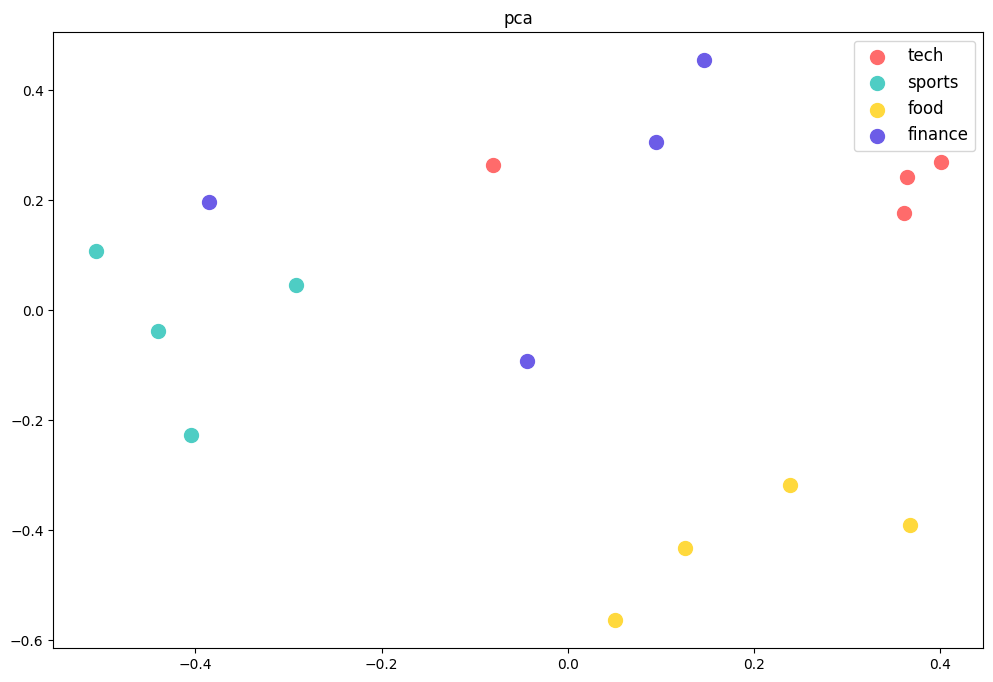

In [69]:
colors = {"tech": "#FF6B6B", "sports": "#4ECDC4", "food": "#FFD93D", "finance": "#6C5CE7"}
fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    x = coords_2d[mask, 0]
    y = coords_2d[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)
    
ax.legend(fontsize=12)
ax.set_title('pca')
plt.show()

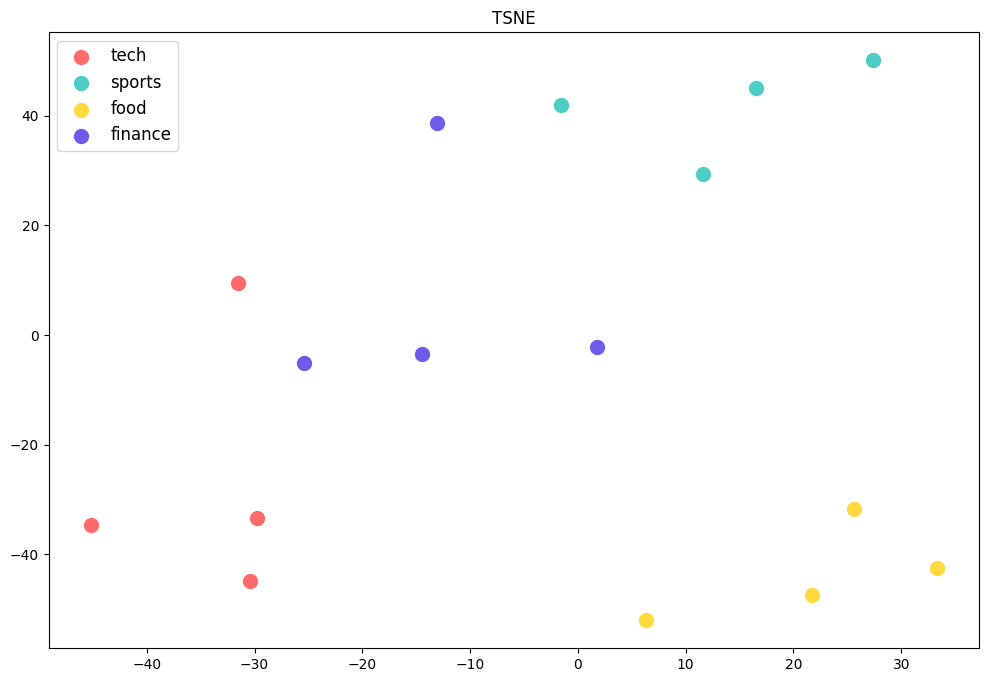

In [73]:
tsne = TSNE(n_components = 2, random_state=42, perplexity=5)
coords_tsne = tsne.fit_transform(emb_matrix)

fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    x = coords_tsne[mask, 0]
    y = coords_tsne[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)
    
ax.legend(fontsize=12)
ax.set_title('TSNE')
plt.show()

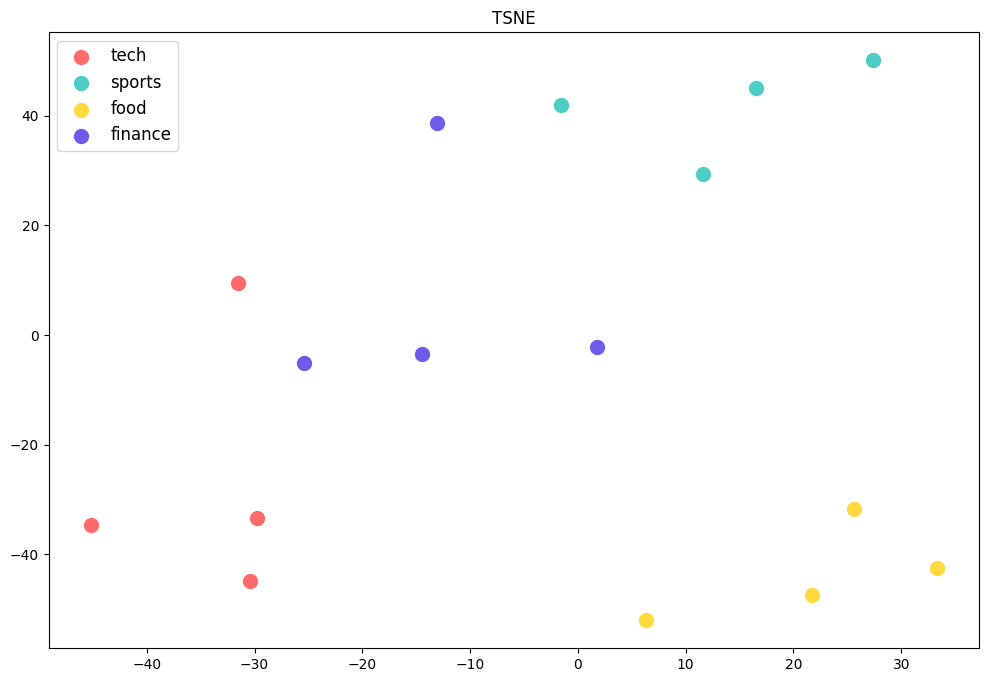

In [74]:
tsne = TSNE(n_components = 2, random_state=42, perplexity=5)
coords_tsne = tsne.fit_transform(emb_matrix)

fig, ax = plt.subplots(figsize=(12, 8))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    x = coords_tsne[mask, 0]
    y = coords_tsne[mask, 1]
    ax.scatter(x, y, c=colors[topic], label=topic, s=100)
    
ax.legend(fontsize=12)
ax.set_title('TSNE')
plt.show()

In [ ]:
# FAISS (Facebook AI Similarity Search)

In [75]:
from langchain_community.vectorstores import FAISS

In [76]:
faq_docs = [
    "LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.",
    "RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.",
    "벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.",
    "프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.",
    "파인튜닝은 사전학습된 모델을 특정 도메인 데이터로 추가 학습시킵니다.",
    "토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.",
    "LCEL은 LangChain의 체인 구성을 위한 표현식 언어입니다.",
    "에이전트는 LLM이 도구를 사용해서 자율적으로 작업하는 시스템입니다.",
    "Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.",
]

In [77]:
vectorstore = FAISS.from_texts(faq_docs, embedding_model)

In [80]:
queries = [
    "RAG가 뭐에요?", "AI 챗봇을 어떻게 만드나요?", "토큰 비용을 줄이려면?"
]

for query in queries:
    results = vectorstore.similarity_search_with_score(query, k=3)
    for doc, score in results:
        print(f" [{score}] {doc.page_content}")
    print("============")

 [0.9825575947761536] RAG는 외부 문서를 검색하여 LLM 답변 정확도를 높이는 기술입니다.
 [1.4886493682861328] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
 [1.5458478927612305] LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.
 [1.4890832901000977] 프롬프트 엔지니어링은 AI에게 효과적인 지시를 작성하는 기술입니다.
 [1.5326212644577026] Gradio는 ML 모델을 위한 간단한 웹 인터페이스를 만드는 라이브러리입니다.
 [1.5811690092086792] LangChain은 LLM 애플리케이션 개발을 위한 프레임워크입니다.
 [1.2465994358062744] 토큰은 LLM이 텍스트를 처리하는 기본 단위입니다.
 [1.3880542516708374] 임베딩은 텍스트를 수치 벡터로 변환하는 기술입니다.
 [1.4391734600067139] 벡터 데이터베이스는 임베딩 벡터를 효율적으로 저장하고 검색합니다.


In [82]:
from langchain_core.documents import Document

In [83]:
docs_with_meta = [
    Document(page_content = 'Langchain은 LLM앱 개발 프레임워크입니다', metadata = {'category' : 'framework', 'level' : 'beginner'}),
    Document(page_content = 'RAG는 검색증강생성 기술입니다', metadata = {'category' : 'technique', 'level' : 'intermediate'}),
    Document(page_content = 'FAISS는 벡터 유사도 검색 라이브러리입니다', metadata = {'category' : 'tool', 'level' : 'intermediate'}),
    Document(page_content = '프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다', metadata = {'category' : 'technique', 'level' : 'beginner'}),
    Document(page_content = '에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다', metadata = {'category' : 'technique', 'level' : 'advanced'}),
]

vs_meta = FAISS.from_documents(docs_with_meta, embedding_model)

In [85]:
results = vs_meta.similarity_search('AI 개발 도구', k=3)
results

[Document(id='6bb0096a-9ca5-4964-8b7f-ad8c42ac7d71', metadata={'category': 'technique', 'level': 'beginner'}, page_content='프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다'),
 Document(id='79e722f8-4eb6-4b06-81e9-6b0008fc95e0', metadata={'category': 'technique', 'level': 'advanced'}, page_content='에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다'),
 Document(id='c130ed5b-43ce-41a4-a720-afaa8e1e5d0a', metadata={'category': 'framework', 'level': 'beginner'}, page_content='Langchain은 LLM앱 개발 프레임워크입니다')]

In [88]:
for doc in results:
    print(f"{doc.metadata['category']}, {doc.metadata['level']}, {doc.page_content}")

technique, beginner, 프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다
technique, advanced, 에이전트는 LLM이 도구를 자율적으로 사용하는 시스템입니다
framework, beginner, Langchain은 LLM앱 개발 프레임워크입니다


In [ ]:
embedding_model = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [ ]:
# 프롬프트 엔지니어링은 AI 지시를 작성하는 기술입니다 -> [3, 109, 1334, 14459, ..] -> 1530 

In [89]:
multilingual = [
    ('인공지능이 세상을 바꾸고 있다', '한국어'),
    ('Artificial inteligence is changing the world', '영어'),
    ('나는 학교에 갑니다', '한국어'),
    ('I go home', '영어')
]

texts = [t for t, l in multilingual]
langs = [l for t, l in multilingual]

In [91]:
langs

['한국어', '영어', '한국어', '영어']

In [92]:
embs_multi = embedding_model.embed_documents(texts)
sim_matrix = cosine_similarity(embs_multi)

In [93]:
sim_matrix

array([[ 1.        ,  0.60158619,  0.09073573,  0.06148136],
       [ 0.60158619,  1.        , -0.01850748,  0.05518189],
       [ 0.09073573, -0.01850748,  1.        ,  0.29727779],
       [ 0.06148136,  0.05518189,  0.29727779,  1.        ]])

In [97]:
english_docs = [
    "LangChain is a framework for building LLM applications.",
    "RAG improves LLM accuracy by retrieving external documents.",
    "Vector databases store and search embedding vectors efficiently.",
    "Fine-tuning adapts a pre-trained model to specific data.",
    "Prompt engineering is the art of crafting effective instructions for AI.",
]

vs_en = FAISS.from_texts(english_docs, embedding_model)

korean_queries = [
    "RAG가 뭐에요?", "벡터 데이터베이스 설명해주세요", "프롬프트 엔지니어링은?"
]

for q in korean_queries:
    results = vs_en.similarity_search_with_score(q, k=3)
    print(f"\nKR {q}")
    for doc, score in results:
        print(f" US {score}, {doc.page_content}")


KR RAG가 뭐에요?
 US 1.0923923254013062, RAG improves LLM accuracy by retrieving external documents.
 US 1.6639251708984375, LangChain is a framework for building LLM applications.
 US 1.819159746170044, Prompt engineering is the art of crafting effective instructions for AI.

KR 벡터 데이터베이스 설명해주세요
 US 1.456146478652954, Vector databases store and search embedding vectors efficiently.
 US 1.7263362407684326, RAG improves LLM accuracy by retrieving external documents.
 US 1.781709909439087, Fine-tuning adapts a pre-trained model to specific data.

KR 프롬프트 엔지니어링은?
 US 1.5417664051055908, Prompt engineering is the art of crafting effective instructions for AI.
 US 1.7585232257843018, Vector databases store and search embedding vectors efficiently.
 US 1.772371768951416, Fine-tuning adapts a pre-trained model to specific data.
